# Cherry Blossom — CF Models Per Location

Fits species-specific process-based chill-forcing models **independently at
each station** for *Cerasus yedoensis* (Somei-yoshino), using the GMU Japan
dataset.  The idea is to let the model parameters vary freely across locations
rather than fitting a single set of parameters for the whole species — revealing
how chilling and forcing requirements shift with climate.

| Model | Chilling | Forcing |
|---|---|---|
| `GDDModel` | — (heat from season start) | GDU |
| `UtahGDDModel` | Utah chill units | GDU after chill gate |
| `ChillingDaysGDDModel` | Days ≤ *t_chill* | GDU after chill gate |
| `DynamicGDDModel` | Dynamic chill portions | GDU after chill gate |

In [4]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns

from pysephone.constants import KEY_FEATURES
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.openmeteo import OpenMeteoFeatures
from pysephone.evaluation.regression import SingleTargetRegression
from pysephone.models.gdd import GDDModel
from pysephone.models.cf import (
    UtahGDDModel,
    ChillingDaysGDDModel,
    DynamicGDDModel,
)

In [5]:
# ── Configuration ────────────────────────────────────────────────────────────
DATASET_KEY      = 'GMU_Cherry_Japan_YS'
SPECIES_KEY      = ('GMU_cherry', 0)   # yedoensis
OBS_KEY          = 'gmu_0'
CUTOFF           = 2010                # train < CUTOFF, test >= CUTOFF
MIN_TRAIN_YEARS  = 10                  # skip locations with fewer training years
OPT_MAX_TIME     = 30.0               # seconds per optimisation phase per fit

OPT_KW = dict(opt_max_time=OPT_MAX_TIME)

MODEL_SPECS = [
    ('GDD',              GDDModel,             dict(threshold=200.0, t_base=4.0, **OPT_KW)),
    ('Utah+GDD',         UtahGDDModel,         dict(threshold_c=50.0, threshold_f=200.0, t_base=4.0, **OPT_KW)),
    ('ChillingDays+GDD', ChillingDaysGDDModel, dict(threshold_c=50.0, threshold_f=200.0, **OPT_KW)),
    ('Dynamic+GDD',      DynamicGDDModel,      dict(threshold_c=50.0, threshold_f=200.0, t_base=4.0, **OPT_KW)),
]
MODEL_NAMES = [n for n, _, _ in MODEL_SPECS]

_STYLE = {
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#e0e0e0',
    'grid.linewidth':    0.6,
    'axes.axisbelow':    True,
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
}

## 1. Load data

In [6]:
cal      = Calendar(default_start='10-01', default_length=365)
features = OpenMeteoFeatures(calendar=cal)

ds_ys = Dataset.load(DATASET_KEY, calendar=cal, feature_providers=[features])
ds_ys.download_features(verbose=True)

ds = ds_ys.select_species([SPECIES_KEY])

obs = ds.observations
all_locations = sorted(ds.locations)

print(f'Yedoensis: {len(ds)} samples | '
      f'years {min(ds.years)}–{max(ds.years)} | '
      f'{len(all_locations)} locations')

Preloading features: 100%|██████████| 2222/2222 [00:26<00:00, 84.61it/s]

Yedoensis: 1997 samples | years 1986–2021 | 67 locations


## 2. Temporal split and location filtering

Only locations with at least `MIN_TRAIN_YEARS` training observations are kept
— locations with too few years cannot reliably constrain the model parameters.

In [7]:
def temporal_split(ds, cutoff):
    years = sorted(ds.years)
    return (ds.select_years([y for y in years if y < cutoff]),
            ds.select_years([y for y in years if y >= cutoff]))


ds_trn_all, ds_tst_all = temporal_split(ds, CUTOFF)

# Build per-location metadata and filter by training size
loc_info = []  # list of dicts
for loc in all_locations:
    ds_loc_trn = ds_trn_all.select_locations([loc])
    ds_loc_tst = ds_tst_all.select_locations([loc])
    n_trn = len(ds_loc_trn)
    n_tst = len(ds_loc_tst)
    coords = obs.get_location_coordinates(loc)
    name   = obs.get_location_name(loc) or str(loc)
    loc_info.append(dict(
        loc=loc, name=name,
        lat=coords['lat'], lon=coords['lon'],
        n_trn=n_trn, n_tst=n_tst,
        keep=(n_trn >= MIN_TRAIN_YEARS),
    ))

df_locs = pd.DataFrame(loc_info)
kept    = df_locs[df_locs['keep']]
skipped = df_locs[~df_locs['keep']]

print(f'Locations kept   (n_train >= {MIN_TRAIN_YEARS}): {len(kept)}')
print(f'Locations skipped:                              {len(skipped)}')
if len(skipped):
    print('  Skipped:', skipped['name'].tolist())

Locations kept   (n_train >= 10): 66
Locations skipped:                              1
  Skipped: ['Japan/Nobeoka']


## 3. Fit models per location

In [16]:
target_fn = lambda s: s['observations'][OBS_KEY]

fitted  = {}   # loc -> {model_name: model}
results = {}   # loc -> {model_name: SingleTargetRegression}

n_total = len(kept) * len(MODEL_SPECS)
n_done  = 0

for _, row in kept.iterrows():
    loc     = row['loc']
    name    = row['name']
    ds_l_tr = ds_trn_all.select_locations([loc])
    ds_l_te = ds_tst_all.select_locations([loc])

    fitted[loc]  = {}
    results[loc] = {}

    for model_name, cls, kwargs in MODEL_SPECS:
        model, _ = cls.fit(
            target_fn=target_fn,
            dataset=ds_l_tr,
            model_kwargs=dict(kwargs),
        )
        fitted[loc][model_name] = model

        loc_slug = str(loc[1]).lower().replace(' ', '_')
        results[loc][model_name] = SingleTargetRegression.run(
            model=model,
            dataset_train=ds_l_tr,
            dataset_test=ds_l_te if len(ds_l_te) > 0 else None,
            target_fn=target_fn,
            run_name=f'{model_name.lower().replace("+", "_")}_loc_{loc_slug}',
        )

        n_done += 1
        if n_done % 20 == 0 or n_done == n_total:
            print(f'  {n_done}/{n_total} fits done')

print('All fits complete.')

  20/264 fits done
  40/264 fits done
  60/264 fits done
  80/264 fits done
  100/264 fits done
  120/264 fits done
  140/264 fits done
  160/264 fits done
  180/264 fits done
  200/264 fits done
  220/264 fits done
  240/264 fits done
  260/264 fits done
  264/264 fits done
All fits complete.


## 4. Metrics summary

In [17]:
# Plain dict for O(1) lookup — avoids pandas misinterpreting tuples as multi-index keys
loc_to_info = {row['loc']: row for _, row in kept.iterrows()}

metric_rows = []
for loc, model_dict in results.items():
    info = loc_to_info[loc]
    for model_name, result in model_dict.items():
        m = result.compute_metrics()
        for split in ('train', 'test'):
            if not m[split]:
                continue
            metric_rows.append({
                'loc':   loc,
                'name':  info['name'],
                'lat':   info['lat'],
                'lon':   info['lon'],
                'model': model_name,
                'split': split,
                **{k: round(v, 3) for k, v in m[split].items()},
            })

df_metrics = pd.DataFrame(metric_rows)

# Summary table: median across locations per model × split
summary = (
    df_metrics
    .groupby(['model', 'split'])[['rmse', 'mae', 'r2', 'bias']]
    .median()
    .round(2)
)
print('Median metrics across locations:')
display(summary)

Median metrics across locations:


/home/ron/Repositories/pysephone/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ron/Repositories/pysephone/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/ron/Repositories/pysephone/src/pysephone/evaluation/regression.py:252: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  tau = float(kendalltau(obs, pred).statistic)


rmse   mae    r2  bias
model            split                         
ChillingDays+GDD test    2.94  2.25  0.62  0.83
                 train   2.64  1.92  0.68  0.12
Dynamic+GDD      test    3.34  2.62  0.49  0.17
                 train   2.61  2.08  0.68  0.18
GDD              test   11.37  9.00 -5.09 -2.42
                 train   8.93  6.96 -3.10  1.51
Utah+GDD         test    4.35  3.21 -0.07  1.62
                 train   3.48  2.59  0.44  0.40

## 5. RMSE distribution per model

Violin plots of per-location test RMSE — shows the spread across stations,
not just the average.

/tmp/ipykernel_28346/3903165926.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_28346/3903165926.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


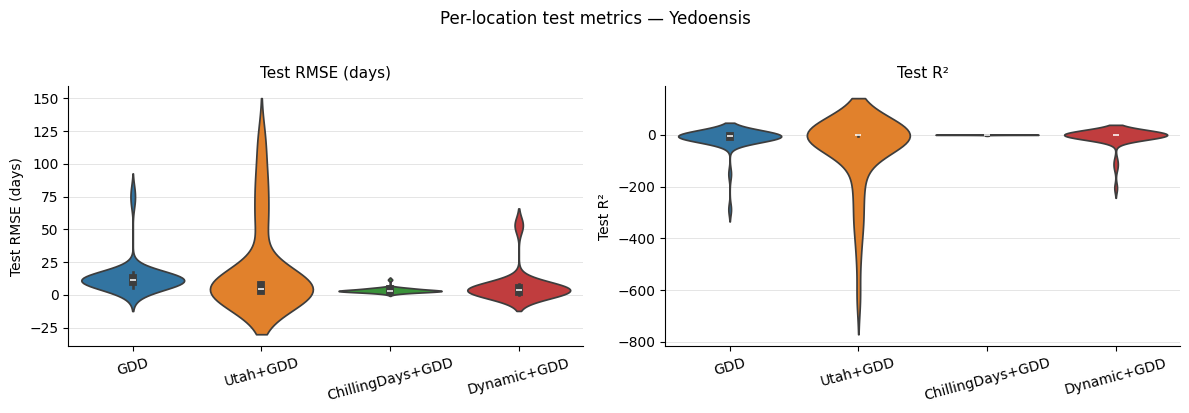

In [18]:
df_test = df_metrics[df_metrics['split'] == 'test'].copy()

with plt.rc_context(_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, metric, label in [
        (axes[0], 'rmse', 'Test RMSE (days)'),
        (axes[1], 'r2',   'Test R²'),
    ]:
        sns.violinplot(
            data=df_test, x='model', y=metric,
            order=MODEL_NAMES, inner='box',
            palette='tab10', ax=ax,
        )
        ax.set_xlabel('')
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.tick_params(axis='x', rotation=15)

    fig.suptitle('Per-location test metrics — Yedoensis', y=1.02)
    plt.tight_layout()
    plt.show()

## 6. Spatial maps of test RMSE

Each station is coloured by its test RMSE for the best-performing model
and then for each individual model.

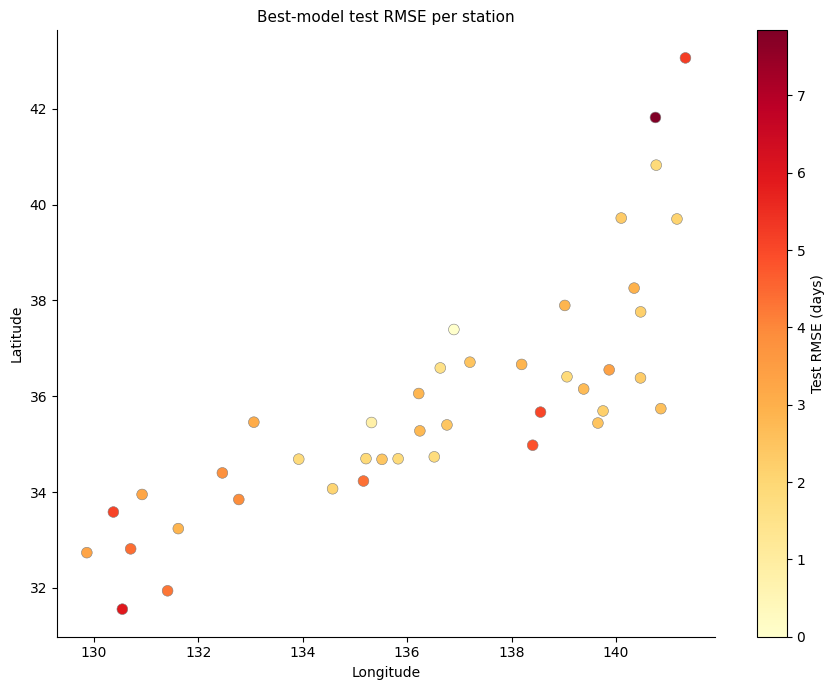

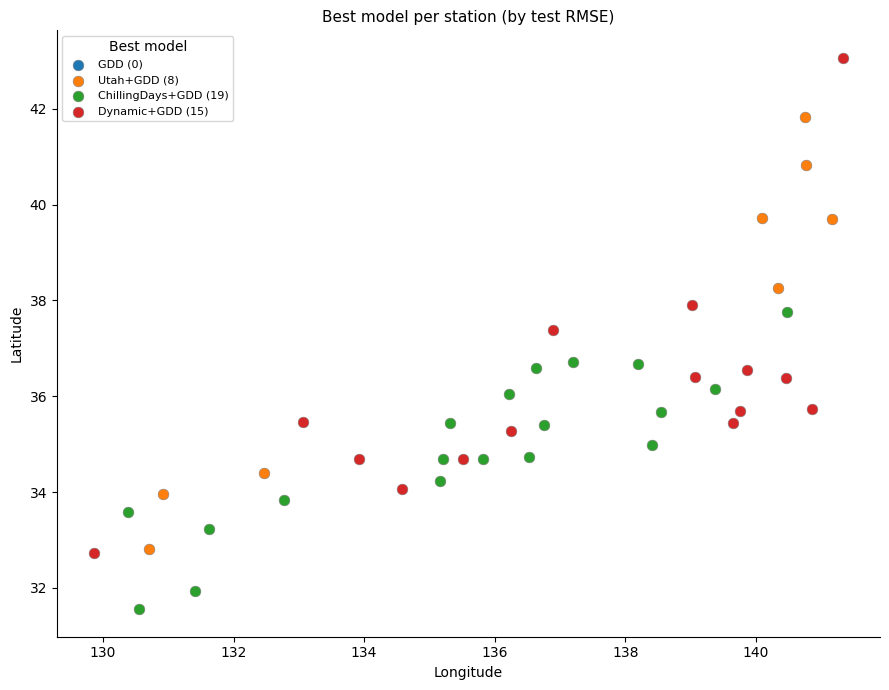

In [19]:
# Best model per location (lowest test RMSE)
best_per_loc = (
    df_test.sort_values('rmse')
    .groupby('loc')
    .first()
    .reset_index()[['loc', 'name', 'lat', 'lon', 'model', 'rmse', 'r2']]
)

with plt.rc_context({**_STYLE, 'axes.grid': False}):
    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(
        best_per_loc['lon'], best_per_loc['lat'],
        c=best_per_loc['rmse'], cmap='YlOrRd',
        s=60, edgecolors='grey', linewidths=0.4, zorder=3,
    )
    plt.colorbar(sc, ax=ax, label='Test RMSE (days)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Best-model test RMSE per station')
    plt.tight_layout()
    plt.show()

# Which model won at each location?
with plt.rc_context({**_STYLE, 'axes.grid': False}):
    model_palette = dict(zip(MODEL_NAMES, sns.color_palette('tab10', len(MODEL_NAMES))))
    colors = best_per_loc['model'].map(model_palette)

    fig, ax = plt.subplots(figsize=(9, 7))
    for mname in MODEL_NAMES:
        sub = best_per_loc[best_per_loc['model'] == mname]
        ax.scatter(
            sub['lon'], sub['lat'],
            color=model_palette[mname], s=60,
            edgecolors='grey', linewidths=0.4,
            label=f'{mname} ({len(sub)})',
            zorder=3,
        )
    ax.legend(title='Best model', fontsize=8)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Best model per station (by test RMSE)')
    plt.tight_layout()
    plt.show()

## 7. Fitted parameters vs latitude

If chilling or forcing requirements vary systematically along the temperature
gradient (north → south Japan), it should appear as a trend in the fitted
parameters against latitude.

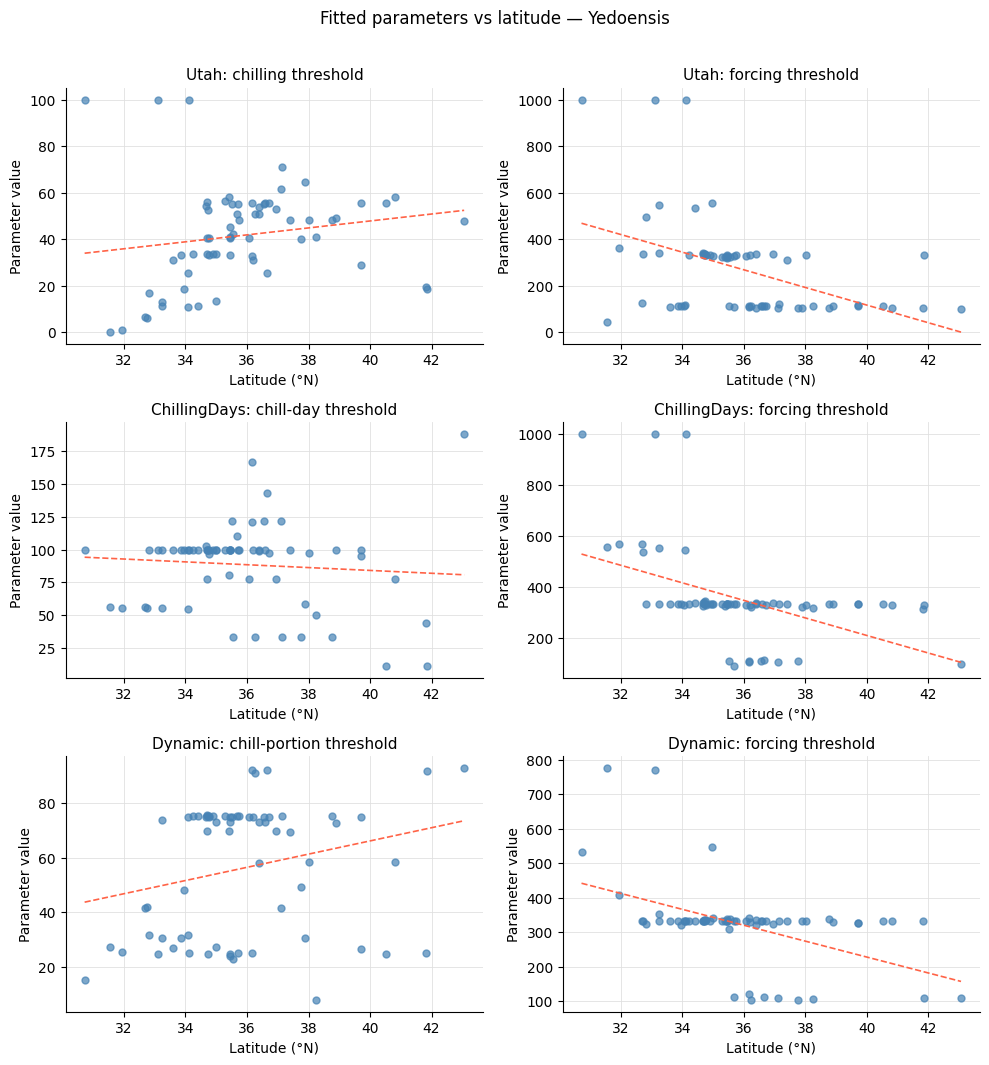

In [20]:
def param_df(model_name, param_key):
    """Collect fitted parameter values across all kept locations."""
    rows = []
    for _, row in kept.iterrows():
        loc = row['loc']
        model = fitted[loc].get(model_name)
        if model is None:
            continue
        val = model.params.get(param_key)
        if val is None:
            continue
        rows.append(dict(lat=row['lat'], lon=row['lon'], name=row['name'], value=val))
    return pd.DataFrame(rows)


PARAM_PLOTS = [
    ('Utah+GDD',         'th_c',  'Utah: chilling threshold'),
    ('Utah+GDD',         'th_f',  'Utah: forcing threshold'),
    ('ChillingDays+GDD', 'th_c',  'ChillingDays: chill-day threshold'),
    ('ChillingDays+GDD', 'th_f',  'ChillingDays: forcing threshold'),
    ('Dynamic+GDD',      'th_c',  'Dynamic: chill-portion threshold'),
    ('Dynamic+GDD',      'th_f',  'Dynamic: forcing threshold'),
]

with plt.rc_context(_STYLE):
    ncols = 2
    nrows = int(np.ceil(len(PARAM_PLOTS) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5))
    axes = axes.flatten()

    for i, (mname, pkey, plabel) in enumerate(PARAM_PLOTS):
        df_p = param_df(mname, pkey)
        ax = axes[i]
        if df_p.empty:
            ax.set_title(f'{plabel}\n(no data)')
            continue

        ax.scatter(df_p['lat'], df_p['value'], s=25, alpha=0.7, color='steelblue')

        # Regression line
        if len(df_p) > 2:
            m_coef = np.polyfit(df_p['lat'], df_p['value'], 1)
            x_line = np.linspace(df_p['lat'].min(), df_p['lat'].max(), 100)
            ax.plot(x_line, np.polyval(m_coef, x_line),
                    color='tomato', linewidth=1.2, linestyle='--')

        ax.set_xlabel('Latitude (°N)')
        ax.set_ylabel('Parameter value')
        ax.set_title(plabel)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Fitted parameters vs latitude — Yedoensis', y=1.01)
    plt.tight_layout()
    plt.show()

## 8. Parameter maps

Spatial distribution of the fitted chilling and forcing thresholds for the
Dynamic+GDD model.

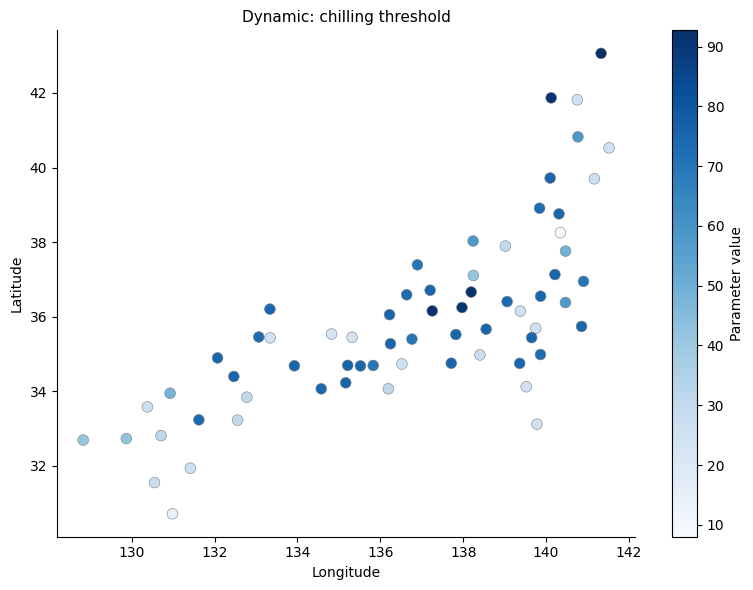

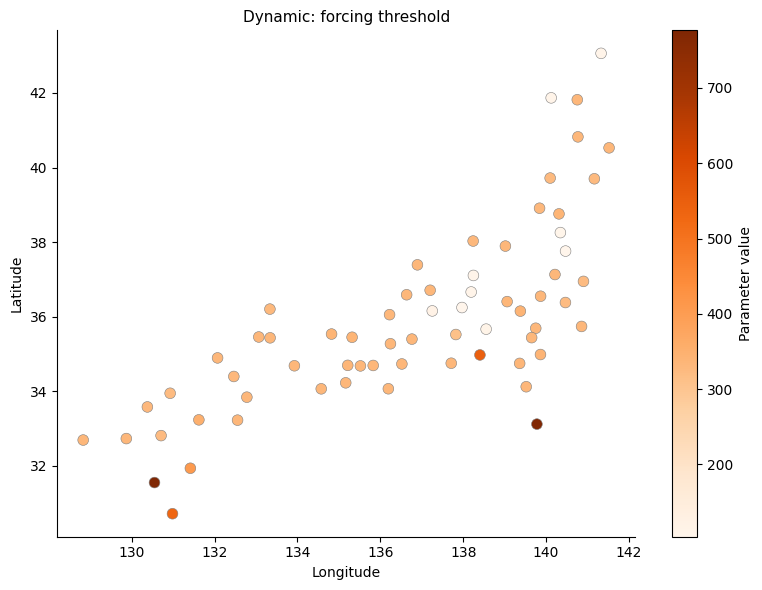

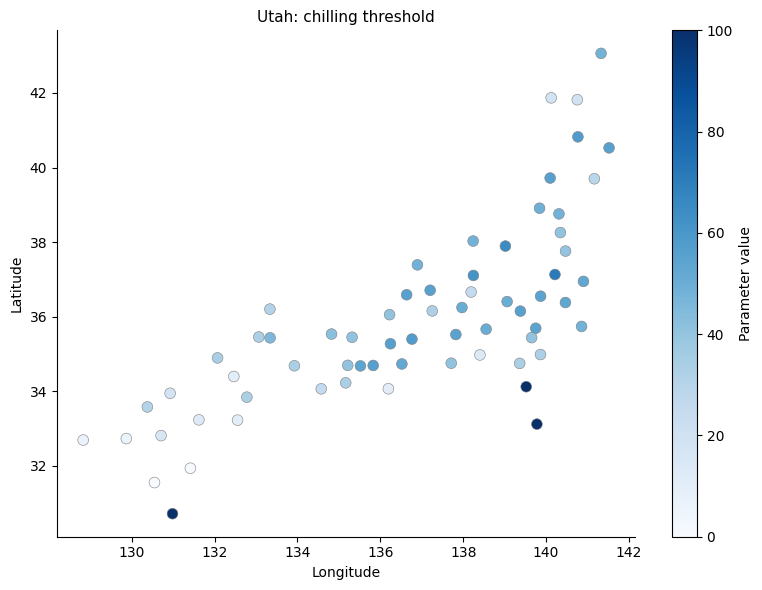

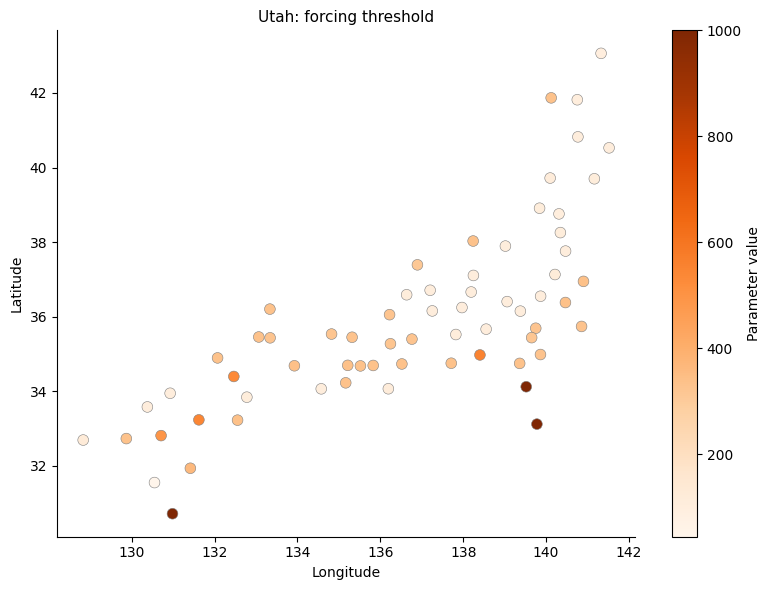

In [21]:
with plt.rc_context({**_STYLE, 'axes.grid': False}):
    for mname, pkey, plabel, cmap in [
        ('Dynamic+GDD', 'th_c', 'Dynamic: chilling threshold',  'Blues'),
        ('Dynamic+GDD', 'th_f', 'Dynamic: forcing threshold',   'Oranges'),
        ('Utah+GDD',    'th_c', 'Utah: chilling threshold',     'Blues'),
        ('Utah+GDD',    'th_f', 'Utah: forcing threshold',      'Oranges'),
    ]:
        df_p = param_df(mname, pkey)
        if df_p.empty:
            continue

        fig, ax = plt.subplots(figsize=(8, 6))
        sc = ax.scatter(
            df_p['lon'], df_p['lat'],
            c=df_p['value'], cmap=cmap,
            s=60, edgecolors='grey', linewidths=0.4, zorder=3,
        )
        plt.colorbar(sc, ax=ax, label='Parameter value')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_title(plabel)
        plt.tight_layout()
        plt.show()

## 9. Per-location scatter — best model

Predicted vs. observed DOY (test split) for each station, coloured by test RMSE.

/home/ron/Repositories/pysephone/src/pysephone/evaluation/regression.py:252: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  tau = float(kendalltau(obs, pred).statistic)


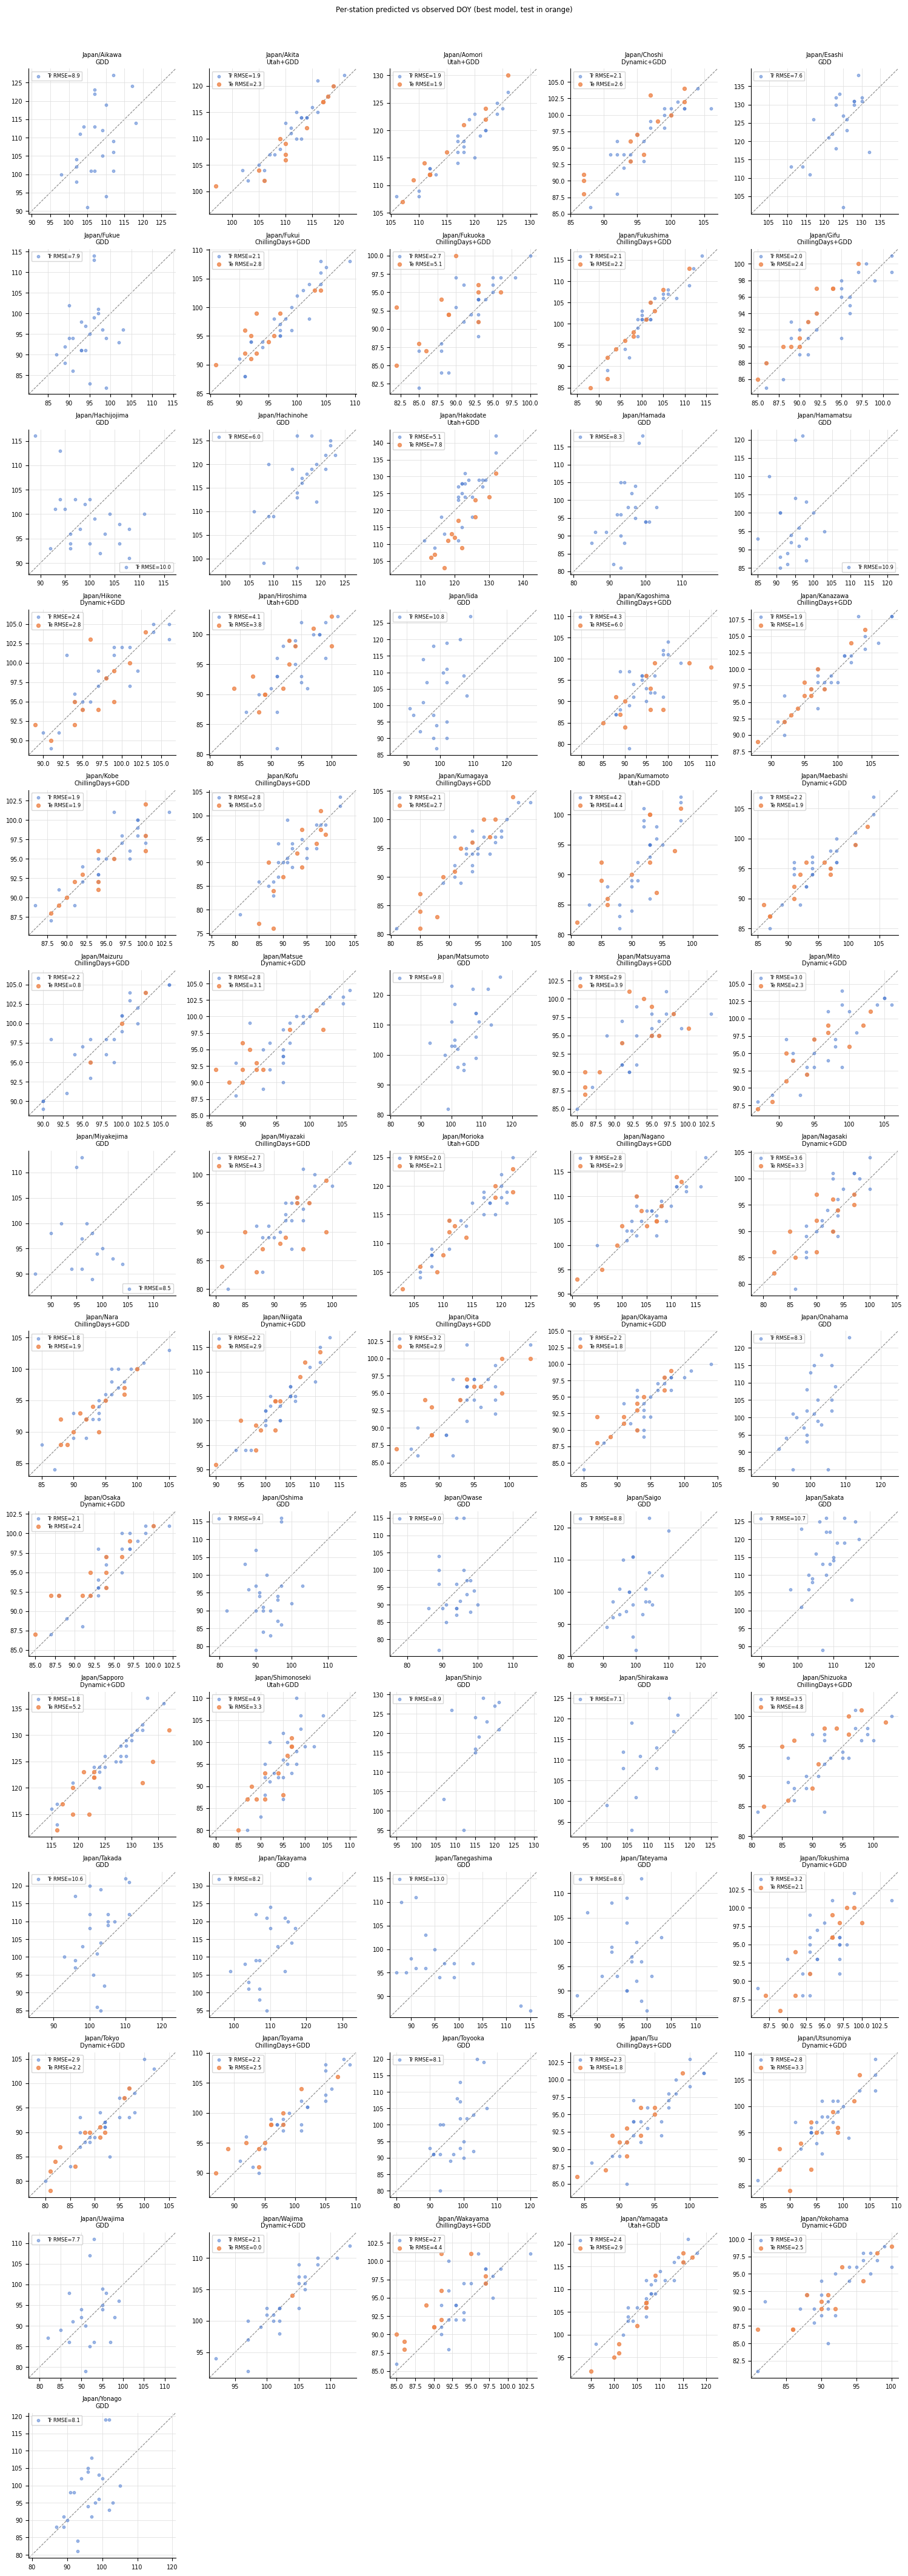

In [22]:
_COLOUR_TRAIN = '#4878d0'
_COLOUR_TEST  = '#ee854a'


def _scatter_ax(ax, result, title):
    m_tr = result.compute_metrics()['train']
    m_te = result.compute_metrics()['test']

    frames = [result.df_train[['predicted_doy', 'observed_doy']]]
    if not result.df_test.empty:
        frames.append(result.df_test[['predicted_doy', 'observed_doy']])
    all_doys = pd.concat(frames)
    lo, hi = all_doys.min().min(), all_doys.max().max()
    pad = (hi - lo) * 0.05 or 1
    lim = (lo - pad, hi + pad)

    ax.plot(lim, lim, color='#888', linewidth=0.8, linestyle='--', zorder=0)
    ax.scatter(
        result.df_train['observed_doy'], result.df_train['predicted_doy'],
        s=10, alpha=0.5, color=_COLOUR_TRAIN, zorder=2,
        label=f"Tr RMSE={m_tr['rmse']:.1f}",
    )
    if not result.df_test.empty:
        ax.scatter(
            result.df_test['observed_doy'], result.df_test['predicted_doy'],
            s=18, alpha=0.8, color=_COLOUR_TEST, zorder=3,
            label=f"Te RMSE={m_te['rmse']:.1f}" if m_te else 'Test',
        )
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_title(title, fontsize=7)
    ax.legend(fontsize=6)


kept_locs = kept['loc'].tolist()
best_model_for = {
    row['loc']: row['model']
    for _, row in best_per_loc.iterrows()
}

ncols = 5
nrows = int(np.ceil(len(kept_locs) / ncols))

with plt.rc_context({**_STYLE, 'axes.grid': True, 'font.size': 7}):
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()

    for i, loc in enumerate(kept_locs):
        mname  = best_model_for.get(loc, MODEL_NAMES[0])
        result = results[loc][mname]
        name   = loc_to_info[loc]['name']
        _scatter_ax(axes[i], result, f'{name}\n{mname}')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Per-station predicted vs observed DOY (best model, test in orange)',
                 y=1.01)
    plt.tight_layout()
    plt.show()

## 10. Test RMSE vs latitude

Does model performance vary along the north–south gradient?  Stations with
an unusual climate (e.g. Okinawa in the far south) may be harder to fit.

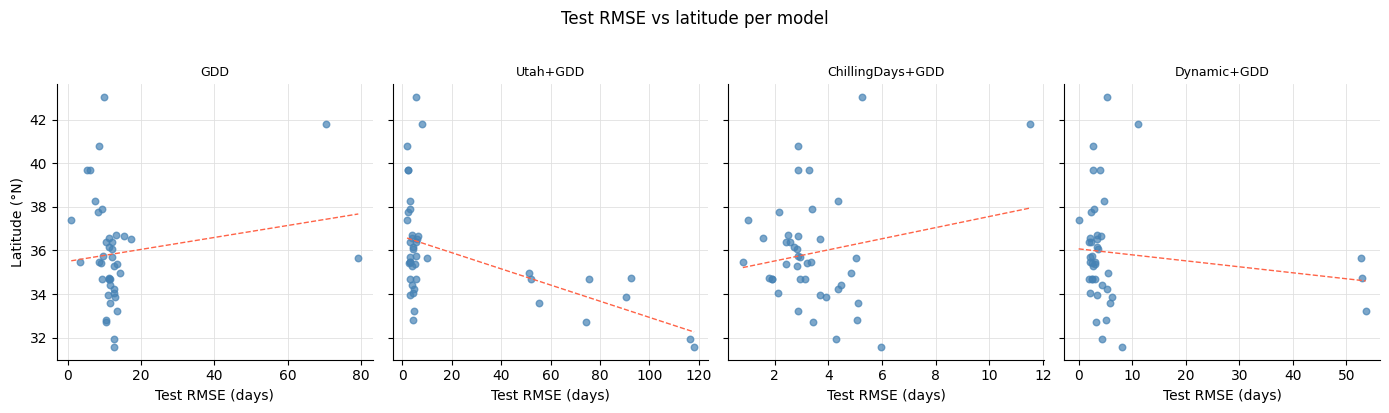

In [23]:
with plt.rc_context(_STYLE):
    fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(len(MODEL_NAMES) * 3.5, 4),
                             sharey=True)

    for ax, mname in zip(axes, MODEL_NAMES):
        sub = df_test[df_test['model'] == mname]
        ax.scatter(sub['rmse'], sub['lat'], s=22, alpha=0.7, color='steelblue')

        if len(sub) > 2:
            coef = np.polyfit(sub['rmse'], sub['lat'], 1)
            x_r  = np.linspace(sub['rmse'].min(), sub['rmse'].max(), 100)
            ax.plot(x_r, np.polyval(coef, x_r),
                    color='tomato', linewidth=1.0, linestyle='--')

        ax.set_xlabel('Test RMSE (days)')
        ax.set_title(mname, fontsize=9)

    axes[0].set_ylabel('Latitude (°N)')
    fig.suptitle('Test RMSE vs latitude per model', y=1.02)
    plt.tight_layout()
    plt.show()